#CUSTOMER SEGMENTATION ANALYSIS


In [9]:
import pandas as pd
df=pd.read_csv('/content/ifood_df.csv')
df.head(3)



,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,0,0,1,0,0,1529,1441,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,0,0,1,0,0,21,15,0
2,71613.0,0,0,26,426,49,127,111,21,42,...,1,0,0,0,1,0,0,734,692,0


###Data exploration and EDA


In [7]:
df.columns

Index(['Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Customer_Days', 'marital_Divorced', 'marital_Married',
       'marital_Single', 'marital_Together', 'marital_Widow',
       'education_2n Cycle', 'education_Basic', 'education_Graduation',
       'education_Master', 'education_PhD', 'MntTotal', 'MntRegularProds',
       'AcceptedCmpOverall'],
      dtype='object')

In [5]:
df.shape

(2205, 39)

In [2]:
df.isnull().sum()

,0
Income,0
Kidhome,0
Teenhome,0
Recency,0
MntWines,0
MntFruits,0
MntMeatProducts,0
MntFishProducts,0
MntSweetProducts,0
MntGoldProds,0


In [4]:
df.describe()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
count,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,...,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.00000
mean,51622.094785,0.442177,0.506576,49.009070,306.164626,26.403175,165.312018,37.756463,27.128345,44.057143,...,0.257596,0.034467,0.089796,0.024490,0.504762,0.165079,0.215873,562.764626,518.707483,0.29932
std,20713.063826,0.537132,0.544380,28.932111,337.493839,39.784484,217.784507,54.824635,41.130468,51.736211,...,0.437410,0.182467,0.285954,0.154599,0.500091,0.371336,0.411520,575.936911,553.847248,0.68044
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,-283.000000,0.00000
25%,35196.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,56.000000,42.000000,0.00000
50%,51287.000000,0.000000,0.000000,49.000000,178.000000,8.000000,68.000000,12.000000,8.000000,25.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,343.000000,288.000000,0.00000
75%,68281.000000,1.000000,1.000000,74.000000,507.000000,33.000000,232.000000,50.000000,34.000000,56.000000,...,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,964.000000,884.000000,0.00000
max,113734.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2491.000000,2458.000000,4.00000


In [11]:
df.nunique()

,0
Income,1963
Kidhome,3
Teenhome,3
Recency,100
MntWines,775
MntFruits,158
MntMeatProducts,551
MntFishProducts,182
MntSweetProducts,176
MntGoldProds,212


In [12]:
df.drop(columns=['Z_CostContact','Z_Revenue'], inplace=True)

########outlier detection through boxplot


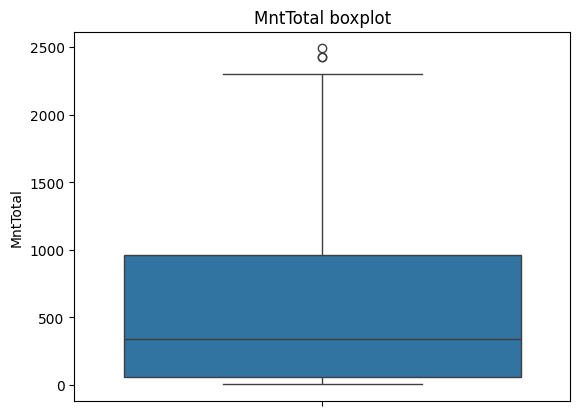

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(data=df,y='MntTotal')
plt.title('MntTotal boxplot')
plt.ylabel('MntTotal')
plt.show()


In [17]:
Q1=df['MntTotal'].quantile(0.25)
Q3=df['MntTotal'].quantile(0.75)
IQR=Q3-Q1
ll=Q1-IQR*1.5
uu=Q3+IQR*1.5
OUTLIER=df[(df['MntTotal']>uu)|(df['MntTotal']<ll)]
OUTLIER.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
1159,90638.0,0,0,29,1156,120,915,94,144,96,...,0,0,0,0,0,1,0,2429,2333,1
1467,87679.0,0,0,62,1259,172,815,97,148,33,...,1,0,0,0,1,0,0,2491,2458,3
1547,90638.0,0,0,29,1156,120,915,94,144,96,...,0,0,0,0,0,1,0,2429,2333,1


In [18]:
df=df[(df['MntTotal']<uu)|(df['MntTotal']>ll)]
df.describe()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
count,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,...,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.00000
mean,51622.094785,0.442177,0.506576,49.009070,306.164626,26.403175,165.312018,37.756463,27.128345,44.057143,...,0.257596,0.034467,0.089796,0.024490,0.504762,0.165079,0.215873,562.764626,518.707483,0.29932
std,20713.063826,0.537132,0.544380,28.932111,337.493839,39.784484,217.784507,54.824635,41.130468,51.736211,...,0.437410,0.182467,0.285954,0.154599,0.500091,0.371336,0.411520,575.936911,553.847248,0.68044
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,-283.000000,0.00000
25%,35196.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,56.000000,42.000000,0.00000
50%,51287.000000,0.000000,0.000000,49.000000,178.000000,8.000000,68.000000,12.000000,8.000000,25.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,343.000000,288.000000,0.00000
75%,68281.000000,1.000000,1.000000,74.000000,507.000000,33.000000,232.000000,50.000000,34.000000,56.000000,...,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,964.000000,884.000000,0.00000
max,113734.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2491.000000,2458.000000,4.00000


In [19]:
#Descriptive statistics
#average purchase value
df['TotalPurchases'] = (
    df['NumWebPurchases'] +
    df['NumCatalogPurchases'] +
    df['NumStorePurchases']
)


In [20]:
avg_income = df['Income'].mean()
print("Average Income:", avg_income)


Average Income: 51622.0947845805


In [21]:
avg_spending = df['MntTotal'].mean()
print("Average Total Spending:", avg_spending)


Average Total Spending: 562.7646258503402


In [22]:
avg_frequency = df['TotalPurchases'].mean()
print("Average Purchase Frequency:", avg_frequency)


Average Purchase Frequency: 12.569614512471656


In [23]:
avg_recency = df['Recency'].mean()
print("Average Recency:", avg_recency)


Average Recency: 49.00907029478458


In [24]:
product_spending = df[[
    'MntWines',
    'MntMeatProducts',
    'MntFruits',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds'
]].mean()

print(product_spending)


MntWines            306.164626
MntMeatProducts     165.312018
MntFruits            26.403175
MntFishProducts      37.756463
MntSweetProducts     27.128345
MntGoldProds         44.057143
dtype: float64


In [25]:
correlation = df['Income'].corr(df['MntTotal'])
print("Correlation between Income and Total Spending:", correlation)


Correlation between Income and Total Spending: 0.8230660021398378


In [26]:
web_analysis = df[['NumWebVisitsMonth', 'TotalPurchases']].corr()
print(web_analysis)


                   NumWebVisitsMonth  TotalPurchases
NumWebVisitsMonth           1.000000       -0.433121
TotalPurchases             -0.433121        1.000000


In [29]:
features = df[['Income', 'Recency', 'TotalPurchases', 'MntTotal']]
features = features.dropna()
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)


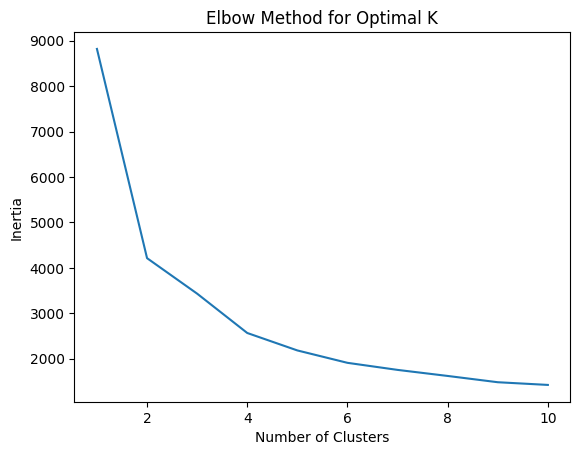

In [30]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()


In [40]:
kmeans = KMeans(n_clusters=4, random_state=42)
df.loc[features.index, 'Cluster'] = kmeans.fit_predict(scaled_features)
cluster_summary = df.groupby('Cluster')[[
    'Income', 'Recency', 'TotalPurchases', 'MntTotal'
]].mean()

print(cluster_summary)


               Income    Recency  TotalPurchases     MntTotal
Cluster                                                      
0.0      70785.909871  23.107296       19.536481  1103.457082
1.0      36356.075658  73.269737        6.888158   118.225329
2.0      36195.582492  22.978114        7.063973   125.207071
3.0      69340.437616  72.811918       19.046555  1080.877095


In [41]:
df['Cluster'].value_counts()


,count
Cluster,
1.0,608
2.0,594
3.0,537
0.0,466


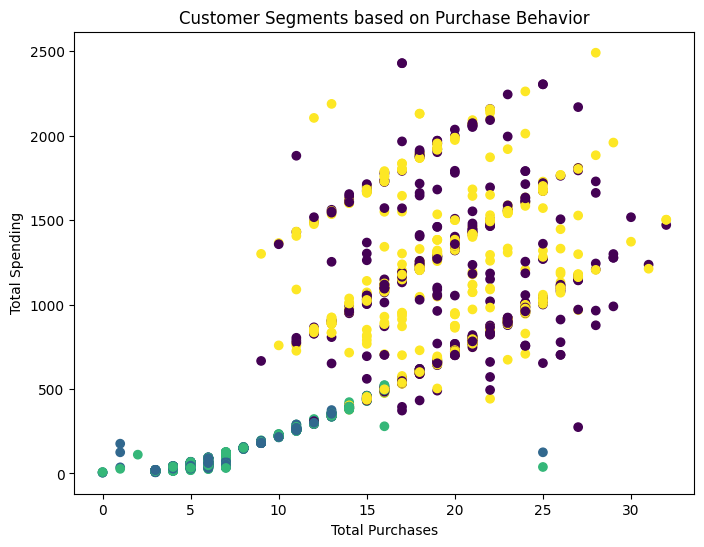

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(
    df['TotalPurchases'],
    df['MntTotal'],
    c=df['Cluster']
)
plt.xlabel("Total Purchases")
plt.ylabel("Total Spending")
plt.title("Customer Segments based on Purchase Behavior")
plt.show()


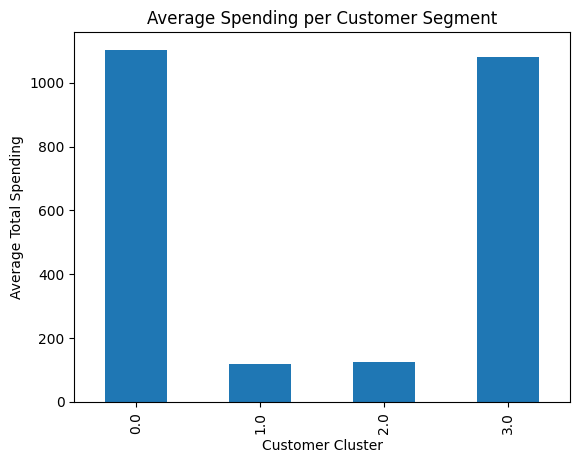

In [36]:
cluster_spending = df.groupby('Cluster')['MntTotal'].mean()

cluster_spending.plot(kind='bar')
plt.xlabel("Customer Cluster")
plt.ylabel("Average Total Spending")
plt.title("Average Spending per Customer Segment")
plt.show()


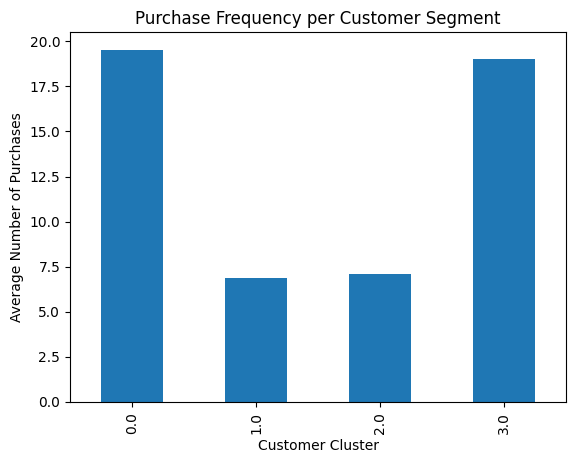

In [37]:
cluster_purchases = df.groupby('Cluster')['TotalPurchases'].mean()

cluster_purchases.plot(kind='bar')
plt.xlabel("Customer Cluster")
plt.ylabel("Average Number of Purchases")
plt.title("Purchase Frequency per Customer Segment")
plt.show()


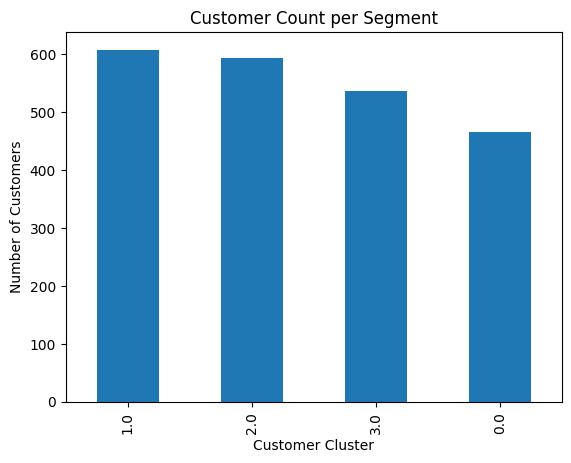

In [38]:
df['Cluster'].value_counts().plot(kind='bar')
plt.xlabel("Customer Cluster")
plt.ylabel("Number of Customers")
plt.title("Customer Count per Segment")
plt.show()


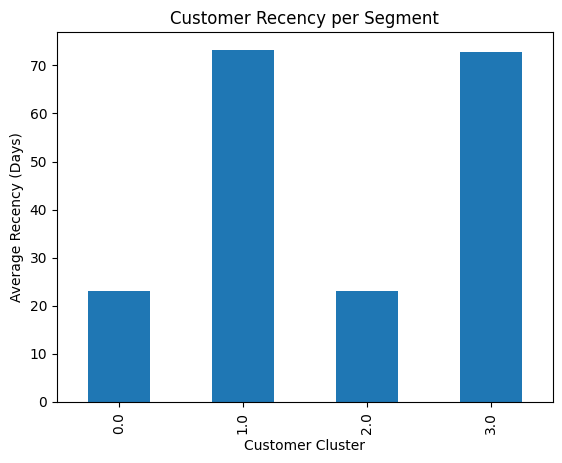

In [39]:
cluster_recency = df.groupby('Cluster')['Recency'].mean()

cluster_recency.plot(kind='bar')
plt.xlabel("Customer Cluster")
plt.ylabel("Average Recency (Days)")
plt.title("Customer Recency per Segment")
plt.show()
